---
title: "A Fischer–Tropsch slurry bubble column, and two typos that stop it working"
description: "Plug-flow large bubbles over a well-mixed slurry. The hydrodynamics reproduce the measured holdup to 5 %, and the reactor reproduces the published conversions — but only after two printed constants are corrected against the paper's own results."
categories: [sec:F, struct:S7, struct:S8, tier:T1, data:tier4, phase:gas-liquid-solid]
date: 2026-07-30
---

# A Fischer–Tropsch slurry bubble column, and two typos that stop it working

**Catalog ID:** `F2.3` · **Structures:** `S7` (multiphase coupling), `S8` (reactor
+ transport) · **Tier:** T1

A commercial Fischer–Tropsch slurry reactor is 7 m across and 30 m tall, and the
gas inside it travels two completely different ways. Small bubbles drift with the
liquid and have all the residence time in the world. Large bubbles tear through
in under a minute. Getting the split wrong changes the predicted conversion by
tens of percent.

This page builds Maretto and Krishna's model of that reactor. The hydrodynamics
are checked against measured holdup; the reactor is checked against the
conversions the authors report — which it only reaches after two printed
constants are corrected.

## Background

The two-bubble-class picture comes straight from `F1.4`: above the regime
transition a churn-turbulent column carries a **dilute phase** of fast large
bubbles and a **dense phase** of liquid with small bubbles entrained in it.

For a *slurry* reactor two things change. Catalyst particles promote coalescence,
which destroys small bubbles — so the dense-phase holdup collapses as solids are
added, and by about 38 vol % solids the small-bubble population is essentially
gone. And pressure works the other way: a commercial reactor runs at 30 bar where
the gas is 7 kg/m³ rather than 1.3, which pushes the transition to higher
velocity and puts *more* gas into small bubbles.

The reactor model then couples three things: large bubbles in plug flow, small
bubbles and slurry treated as well mixed, and Fischer–Tropsch kinetics on cobalt.
That combination — a distributed phase exchanging with lumped phases — is the
`S7`/`S8` structure, and it is what pymrm is for.

## The published model

**Hydrodynamics.** Small-bubble holdup falls linearly with solids (Eq. 7) and
their rise velocity grows (Eq. 8); the pressure correction is Eq. 11:

$$
\varepsilon_{df} = \varepsilon_{df,\mathrm{ref}}
\left(\frac{\rho_G}{\rho_{G,\mathrm{ref}}}\right)^{0.48}
\left(1 - \frac{0.7}{\varepsilon_{df,\mathrm{ref}}}\varepsilon_s\right),
\qquad
V_{\mathrm{small}} = V_{\mathrm{small,ref}} + 0.8\,\varepsilon_s,
$$

$$
U_{df} = \varepsilon_{df} V_{\mathrm{small}},\qquad
\varepsilon_b = 0.3\,D_T^{-0.18}\,(U-U_{df})^{0.58},\qquad
\varepsilon = \varepsilon_b + \varepsilon_{df}(1-\varepsilon_b).
$$

with $\varepsilon_{df,\mathrm{ref}} = 0.27$ and $V_{\mathrm{small,ref}} = 0.095$
m/s for paraffin oil. **Eq. 9's coefficient is 0.3 here, against 0.268 in `F1.4`**
— the earlier paper fitted gas–liquid systems, this one slurries above
$\varepsilon_s = 0.16$. The diameter dependence is capped at $D_T = 1$ m.

**Mass transfer** is tied to holdup rather than correlated separately (Eqs. 13,
14): $(k_La)_{\mathrm{large}} = 0.5\,\varepsilon_b\sqrt{D_L/D_{L,\mathrm{ref}}}$
and $(k_La)_{\mathrm{small}} = 1.0\,\varepsilon_{df}\sqrt{D_L/D_{L,\mathrm{ref}}}$,
with $D_{L,\mathrm{ref}} = 2\times10^{-9}$ m²/s.

**Kinetics** are Yates–Satterfield on cobalt (Eq. 1):

$$-R = \frac{a\,p_{\mathrm{H}_2}p_{\mathrm{CO}}}{(1+b\,p_{\mathrm{CO}})^2}$$

**Reactor.** Large bubbles in plug flow (Eqs. 15–16), small bubbles and slurry
well mixed (Eqs. 17–20), gas contracting as it converts (Eq. 21):

$$
\frac{d}{dz}\Big[(U-U_{df})\,c_{G,i}^{\,\mathrm{large}}\Big]
= -k_La_{i,\mathrm{large}}\left(\frac{c_{G,i}^{\,\mathrm{large}}}{m_i} - c_{L,i}\right),
\qquad
U-U_{df} = (U^i-U_{df})(1+\alpha\chi).
$$

## Parameters and assumptions

Table 1 of the paper: $T$ = 240 °C, $P$ = 30 bar, $D_T$ = 7 m, $H$ = 30 m,
catalyst partial density 647 kg/m³, contraction factor $\alpha = -0.648$ at 5
vol % inert. Solubilities $m_{\mathrm{CO}} = 2.478$, $m_{\mathrm{H}_2} = 2.964$;
diffusivities $45.5$ and $17.2 \times 10^{-9}$ m²/s. Feed H₂/CO = 2, the
consumption ratio, so CO, H₂ and syngas conversions coincide.

### Two printed constants that had to be corrected

Both are stated here rather than applied quietly, and both were resolved against
**the paper's own reported results**, not by guesswork.

**1. The rate prefactor.** Eq. 2 prints
$a = 8.8533\times10^{3}$ mol/(s·kg$_{cat}$·bar²). At reactor conditions that
gives an intrinsic rate of $1.6\times10^{4}$ mol/(s·kg$_{cat}$) — a commercial
cobalt catalyst runs near $10^{-2}$. The paper's own statement that
$\varepsilon_s = 0.30$ gives 96 % conversion at $U = 0.12$ m/s requires
$1.8\times10^{-2}$ mol/(s·kg$_{cat}$), and $8.8533\times10^{-3}$ delivers
$1.6\times10^{-2}$. **The exponent is used as $-3$.** The printed value is off by
$10^{6}$.

**2. What the rate is a rate *of*.** Eq. 1 labels its left side
$-R_{\mathrm{CO+H_2}}$, which reads as syngas. Treated that way — dividing by 3
to get CO — the model gives 71.5 % and 24.1 % where the paper reports 96 % and
63 %. Treated as the **CO** consumption rate it gives 93.1 % and 63.7 %. The
paper's own remark that "$R_{\mathrm{H}_2} = 2R_{\mathrm{CO}}$" is consistent
with the latter. **It is used as the CO rate.**

Neither correction is a free parameter: each is a discrete choice fixed by
published numbers, and the section below shows what the alternatives give.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.optimize import fsolve
from pymrm import construct_div, construct_convflux_upwind
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "F2.3-slurry-bubble-column-ft"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

RGAS, T_R, P_R = 8.314, 513.15, 30e5          # 240 C, 30 bar
DT, H = 7.0, 30.0                              # commercial reactor
EDF_REF, VS_REF = 0.27, 0.095                  # paraffin oil
RHO_G_REF, RHO_G = 1.3, 7.0                    # ambient air, syngas at 30 bar
M_SOL = {"CO": 2.478, "H2": 2.964}
D_L = {"CO": 45.5e-9, "H2": 17.2e-9}
D_L_REF = 2e-9
RHO_P, ALPHA, INERT = 647.0, -0.648, 0.05
A_PRE = 8.8533e-3      # eq. 2, exponent corrected from +3 (see above)
NU_CO = 1.0            # eq. 1 read as the CO rate, not syngas (see above)

## The data

95 markers digitised from Figure 2 — total gas holdup against superficial
velocity at three slurry concentrations in a 0.10 m column. The maintainer
reviewed the extraction and corrected it: where markers overlap the shape
detector picks the wrong glyph, so series identity comes from **which curve a
marker sits on**, not from its matched shape.

A further 20 detections lie inside a merged cluster at the origin. They are
carried in the file with `resolved = no` and an empty `eps_s`, and are excluded
from every number below — reported rather than silently dropped, at the
reviewer's request.

In [3]:
obs = load_data("maretto-krishna-1999-fig2.csv", page=PAGE)
meta = load_meta("maretto-krishna-1999-fig2.csv", page=PAGE)
res = obs[obs.resolved == "yes"].copy()
unres = obs[obs.resolved == "no"]
print(f"{len(obs)} rows: {len(res)} resolved, {len(unres)} in the merged cluster")
for s, g in res.groupby("eps_s"):
    print(f"   eps_s = {s:4.2f}   n = {len(g):3d}   "
          f"U {g.U_m_s.min():.3f}-{g.U_m_s.max():.3f} m/s   "
          f"eps {g.eps_total.min():.3f}-{g.eps_total.max():.3f}")
print(f"\n{cite_data(meta)}")
print(f"review: {meta['review']['verdict']}")

115 rows: 95 resolved, 20 in the merged cluster
   eps_s = 0.00   n =  13   U 0.009-0.491 m/s   eps 0.156-0.483
   eps_s = 0.16   n =  46   U 0.006-0.497 m/s   eps 0.112-0.386
   eps_s = 0.35   n =  36   U 0.021-0.471 m/s   eps 0.069-0.306

Maretto, C.; Krishna, R. (1999) — Catalysis Today 52(2-3) 279-289 — doi:10.1016/S0920-5861(99)00082-6 — digitised from Figure 2, journal page 282
review: positions good, series assignment needed fixing, cluster to be reported not dropped


## PyMRM implementation

The reactor is one distributed phase exchanging with two lumped ones, and that
shape decides the numerics.

**Large bubbles are the only thing with a spatial coordinate.** Their balance is
pure convection with a mass-transfer sink, assembled with
`construct_convflux_upwind` and `construct_div`. Two details matter. The
superficial velocity is **not constant** — the gas contracts as it converts
(Eq. 21) — so the operator is built with a velocity *array* and
$\frac{d}{dz}(Uc)$ is taken as the divergence of the flux, not $U\frac{dc}{dz}$.
And the outlet needs a genuine outflow condition: leaving it unset makes the pure
convection matrix singular.

**Everything else is algebraic.** The small bubbles close in one line, and the
slurry is two scalar unknowns. So the whole reactor reduces to a 2-D root find
over the liquid concentrations, with a pymrm plug-flow solve inside — which is
the same iteration the authors describe.

In [4]:
def hydrodynamics(U, eps_s, d_t=DT, rho_g=RHO_G):
    """Eqs. 7, 8, 9, 10, 11 -> (eps_df, U_df, eps_b, eps_total)."""
    edf = EDF_REF * (rho_g / RHO_G_REF) ** 0.48 * (1.0 - 0.7 / EDF_REF * eps_s)
    vsm = VS_REF + 0.8 * eps_s
    udf = edf * vsm
    eb = 0.3 * min(d_t, 1.0) ** -0.18 * max(U - udf, 1e-12) ** 0.58
    return edf, udf, eb, eb + edf * (1.0 - eb)


def rate_CO(p_H2, p_CO, a_pre=A_PRE):
    """Yates-Satterfield, eqs. 1-3. Returns mol CO /(s kg_cat)."""
    a = a_pre * np.exp(4494.41 * (1 / 493.15 - 1 / T_R))
    b = 2.226 * np.exp(-8236 * (1 / 493.15 - 1 / T_R))
    return a * max(p_H2, 0.0) * max(p_CO, 0.0) / (1.0 + b * max(p_CO, 0.0)) ** 2


def large_bubbles(c_L, c_in, kla, U_i, n=400, alpha=ALPHA):
    """Plug-flow large bubbles, eqs. 15-16 with the contraction of eq. 21."""
    z_f = np.linspace(0.0, H, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    shape = (n, 1)
    div = construct_div(shape, z_f, nu=0)
    c_g = {s: np.full(n, c_in[s]) for s in M_SOL}
    for _ in range(80):
        chi = np.clip(1.0 - (c_g["CO"] + c_g["H2"]) / (c_in["CO"] + c_in["H2"]), 0.0, 0.999)
        U_L = (U_i * (1.0 + alpha * chi)).reshape(-1, 1)
        new = {}
        for s in M_SOL:
            bc = ({"a": 0.0, "b": 1.0, "d": c_in[s]},    # inlet
                  {"a": 1.0, "b": 0.0, "d": 0.0})        # outflow, zero gradient
            conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=U_L)
            A = (div @ conv).tolil()
            A.setdiag(A.diagonal() + kla[s] / M_SOL[s])
            rhs = -np.asarray((div @ conv_bc).todense()).ravel() + kla[s] * c_L[s]
            new[s] = spsolve(A.tocsc(), rhs)
        moved = max(np.max(np.abs(new[s] - c_g[s])) for s in M_SOL)
        c_g = {s: 0.4 * c_g[s] + 0.6 * new[s] for s in M_SOL}
        if moved < 1e-10:
            break
    return c_g


def reactor(U, eps_s, n=400, kla_factor=1.0, a_pre=A_PRE, nu_co=NU_CO):
    """Full model. Returns a dict with holdup, conversion and profiles."""
    edf, udf, eb, eps = hydrodynamics(U, eps_s)
    eps_L, U_i = 1.0 - eps, U - udf
    kla_l = {s: kla_factor * 0.5 * np.sqrt(D_L[s] / D_L_REF) * eb for s in M_SOL}
    kla_s = {s: kla_factor * 1.0 * np.sqrt(D_L[s] / D_L_REF) * edf for s in M_SOL}
    c_tot = P_R / (RGAS * T_R)
    c_in = {"CO": c_tot * (1 - INERT) / 3.0, "H2": c_tot * (1 - INERT) * 2.0 / 3.0}
    cat = eps_L * eps_s * RHO_P                       # kg catalyst per m3 reactor
    dz = H / n

    def small(c_L):                                    # eqs. 17-18, one line
        return {s: (udf * c_in[s] + kla_s[s] * H * c_L[s])
                   / (udf + kla_s[s] * H / M_SOL[s]) for s in M_SOL}

    def residual(v):                                   # eqs. 19-20
        c_L = {"CO": abs(v[0]), "H2": abs(v[1])}
        c_g = large_bubbles(c_L, c_in, kla_l, U_i, n)
        c_s = small(c_L)
        R = rate_CO(c_L["H2"] * M_SOL["H2"] * RGAS * T_R / 1e5,
                    c_L["CO"] * M_SOL["CO"] * RGAS * T_R / 1e5, a_pre)
        out = []
        for s, nu in (("CO", nu_co), ("H2", 2.0 * nu_co)):
            transfer = (np.sum(kla_l[s] * (c_g[s] / M_SOL[s] - c_L[s])) * dz
                        + H * kla_s[s] * (c_s[s] / M_SOL[s] - c_L[s]))
            out.append(transfer - H * cat * nu * R)
        return out

    v = fsolve(residual, [c_in["CO"] / M_SOL["CO"] * 0.05,
                          c_in["H2"] / M_SOL["H2"] * 0.05], xtol=1e-12)
    c_L = {"CO": abs(v[0]), "H2": abs(v[1])}
    c_g = large_bubbles(c_L, c_in, kla_l, U_i, n)
    c_s = small(c_L)
    chi_l = np.clip(1 - (c_g["CO"][-1] + c_g["H2"][-1]) / (c_in["CO"] + c_in["H2"]), 0, 1)
    leaving = U_i * (1 + ALPHA * chi_l) * (c_g["CO"][-1] + c_g["H2"][-1]) \
        + udf * (c_s["CO"] + c_s["H2"])
    entering = (U_i + udf) * (c_in["CO"] + c_in["H2"])
    return dict(eps=eps, eps_df=edf, eps_b=eb, U_df=udf, c_L=c_L, c_g=c_g,
                conversion=1.0 - leaving / entering,
                z=np.linspace(0, H, n + 1)[:-1] + 0.5 * H / n)

print("model assembled")

model assembled


## Results

The hydrodynamics first, against the digitised figure. Note this is a 0.10 m
column at ambient conditions, so the pressure factor of Eq. 11 is unity here.

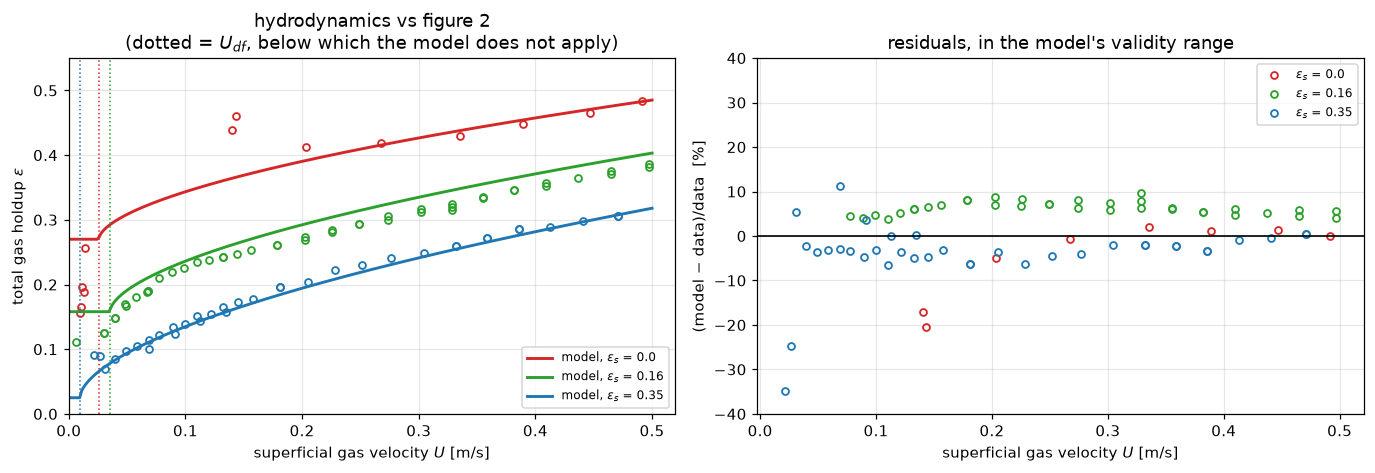

holdup, restricted to U > 2 U_df where the churn-turbulent model applies:
   eps_s = 0.00   U_df = 0.0257   n =   8   mean |dev|  5.9 %   bias  -4.8 %
   eps_s = 0.16   U_df = 0.0352   n =  35   mean |dev|  6.3 %   bias  +6.3 %
   eps_s = 0.35   U_df = 0.0094   n =  36   mean |dev|  4.9 %   bias  -3.7 %


In [5]:
def eps_model(U, eps_s, C=0.3):
    edf = EDF_REF * (1.0 - 0.7 / EDF_REF * eps_s)      # ambient: no pressure factor
    udf = edf * (VS_REF + 0.8 * eps_s)
    eb = C * 0.10 ** -0.18 * np.maximum(U - udf, 1e-12) ** 0.58
    return eb + edf * (1 - eb), udf

fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.4))
cols = {0.0: "tab:red", 0.16: "tab:green", 0.35: "tab:blue"}
UU = np.linspace(0.001, 0.5, 300)
rows = []
for s, g in res.groupby("eps_s"):
    e_mod, udf = eps_model(UU, s)
    ax[0].plot(UU, e_mod, color=cols[s], lw=1.9, label=f"model, $\\epsilon_s$ = {s}")
    ax[0].plot(g.U_m_s, g.eps_total, "o", ms=4.5, mfc="none", mew=1.2, color=cols[s])
    ax[0].axvline(udf, color=cols[s], ls=":", lw=1.0)
    valid = g.U_m_s.values > 2 * udf
    dev = eps_model(g.U_m_s.values[valid], s)[0] / g.eps_total.values[valid] - 1
    rows.append((s, udf, valid.sum(), np.abs(dev).mean(), dev.mean()))
ax[0].set(xlabel="superficial gas velocity $U$ [m/s]", ylabel=r"total gas holdup $\epsilon$",
          title="hydrodynamics vs figure 2\n(dotted = $U_{df}$, below which the model does not apply)",
          xlim=(0, 0.52), ylim=(0, 0.55))
ax[0].legend(fontsize=8)

for s, g in res.groupby("eps_s"):
    _, udf = eps_model(0.1, s)
    v = g.U_m_s.values > 2 * udf
    ax[1].plot(g.U_m_s.values[v],
               (eps_model(g.U_m_s.values[v], s)[0] / g.eps_total.values[v] - 1) * 100,
               "o", ms=4.5, mfc="none", mew=1.2, color=cols[s], label=f"$\\epsilon_s$ = {s}")
ax[1].axhline(0, color="k", lw=1.1)
ax[1].set(xlabel="superficial gas velocity $U$ [m/s]", ylabel="(model $-$ data)/data  [%]",
          title="residuals, in the model's validity range", ylim=(-40, 40))
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print("holdup, restricted to U > 2 U_df where the churn-turbulent model applies:")
for s, udf, n_v, mad, bias in rows:
    print(f"   eps_s = {s:4.2f}   U_df = {udf:.4f}   n = {n_v:3d}   "
          f"mean |dev| {mad*100:4.1f} %   bias {bias*100:+5.1f} %")

In [6]:
# the coefficient question: 0.3 here vs 0.268 in F1.4
print("eq. 9's coefficient, tested on the same points:")
print(f"   {'eps_s':>6}{'C = 0.300':>12}{'C = 0.268':>12}")
for s, g in res.groupby("eps_s"):
    _, udf = eps_model(0.1, s)
    v = g.U_m_s.values > 2 * udf
    U, E = g.U_m_s.values[v], g.eps_total.values[v]
    d3 = np.abs(eps_model(U, s, 0.300)[0] / E - 1).mean()
    d2 = np.abs(eps_model(U, s, 0.268)[0] / E - 1).mean()
    print(f"   {s:6.2f}{d3*100:11.1f} %{d2*100:11.1f} %")
print("   0.3 is the value this paper prints, and it is the more consistent of the")
print("   two across all three slurry concentrations. F1.4's 0.268 was fitted to")
print("   gas-liquid systems with no solids, and it does fit eps_s = 0.16 better -")
print("   but it is clearly worse at 0.35, which is where this paper's range lies.")

eq. 9's coefficient, tested on the same points:
    eps_s   C = 0.300   C = 0.268
     0.00        5.9 %        8.5 %
     0.16        6.3 %        1.5 %
     0.35        4.9 %       12.4 %
   0.3 is the value this paper prints, and it is the more consistent of the
   two across all three slurry concentrations. F1.4's 0.268 was fitted to
   gas-liquid systems with no solids, and it does fit eps_s = 0.16 better -
   but it is clearly worse at 0.35, which is where this paper's range lies.


reactor, eps_s = 0.30:
   U = 0.12 m/s   conversion =  93.1 %
   U = 0.20 m/s   conversion =  88.3 %
   U = 0.30 m/s   conversion =  77.3 %
   U = 0.40 m/s   conversion =  63.8 %
   the paper reports 96 % at U = 0.12 and 63 % at U = 0.40


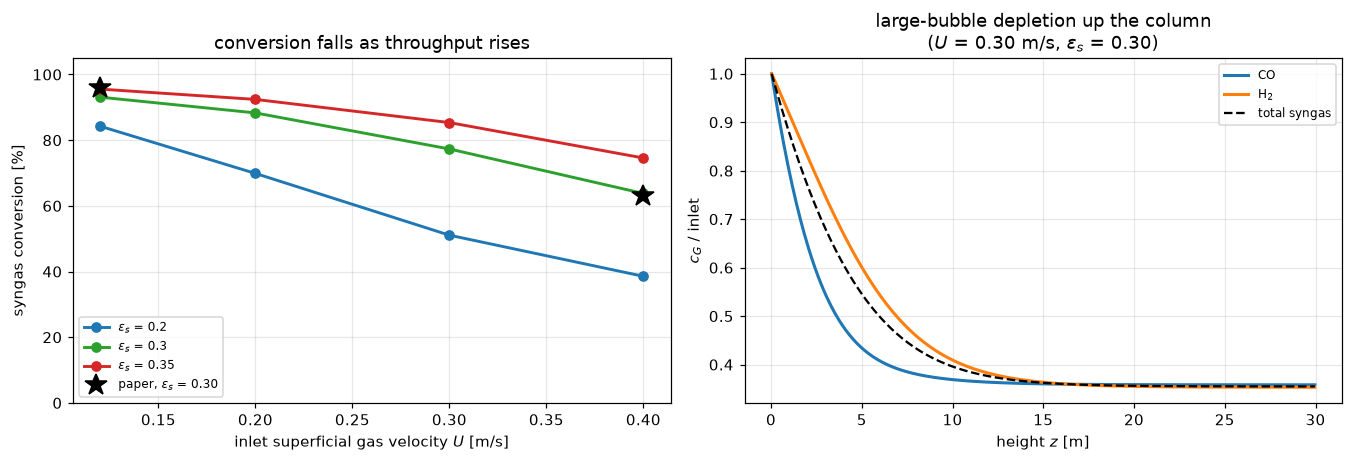

In [7]:
US = np.array([0.12, 0.20, 0.30, 0.40])
conv = np.array([reactor(u, 0.30)["conversion"] for u in US])
print("reactor, eps_s = 0.30:")
for u, c in zip(US, conv):
    print(f"   U = {u:.2f} m/s   conversion = {c*100:5.1f} %")
print(f"   the paper reports 96 % at U = 0.12 and 63 % at U = 0.40")

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.3))
for es, col in ((0.20, "tab:blue"), (0.30, "tab:green"), (0.35, "tab:red")):
    cc = [reactor(u, es)["conversion"] * 100 for u in US]
    ax[0].plot(US, cc, "o-", color=col, lw=1.9, ms=6, label=f"$\\epsilon_s$ = {es}")
ax[0].plot([0.12, 0.40], [96, 63], "k*", ms=15, label="paper, $\\epsilon_s$ = 0.30")
ax[0].set(xlabel="inlet superficial gas velocity $U$ [m/s]",
          ylabel="syngas conversion [%]", ylim=(0, 105),
          title="conversion falls as throughput rises")
ax[0].legend(fontsize=8)

r = reactor(0.30, 0.30)
tot = r["c_g"]["CO"] + r["c_g"]["H2"]
ax[1].plot(r["z"], r["c_g"]["CO"] / r["c_g"]["CO"][0], lw=2, label="CO")
ax[1].plot(r["z"], r["c_g"]["H2"] / r["c_g"]["H2"][0], lw=2, label="H$_2$")
ax[1].plot(r["z"], tot / tot[0], "k--", lw=1.5, label="total syngas")
ax[1].set(xlabel="height $z$ [m]", ylabel="$c_G$ / inlet",
          title="large-bubble depletion up the column\n($U$ = 0.30 m/s, $\\epsilon_s$ = 0.30)")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## Validation

Four checks: the transport operator on its own, the hydrodynamics against
measurement, and two that the paper pays for.

In [8]:
print("1. The convection operator, before trusting it inside the reactor")
Hh, ci_t, Ut, kt = 30.0, 100.0, 0.1, 0.02
errs = []
for n in (50, 200, 800, 3200):
    z_f = np.linspace(0, Hh, n+1); z_c = 0.5*(z_f[:-1]+z_f[1:]); shp = (n, 1)
    div = construct_div(shp, z_f, nu=0)
    bc = ({"a":0.,"b":1.,"d":ci_t}, {"a":1.,"b":0.,"d":0.})
    conv_op, cbc = construct_convflux_upwind(shp, z_f, z_c, bc, v=Ut)
    A = (div@conv_op).tolil(); A.setdiag(A.diagonal()+kt)
    c = spsolve(A.tocsc(), -np.asarray((div@cbc).todense()).ravel())
    errs.append(np.abs(c - ci_t*np.exp(-kt*z_c/Ut)).max()/ci_t)
    print(f"   n = {n:4d}   max rel err vs analytic exp(-kz/U)  {errs[-1]:.3e}")
print(f"   ratios {np.round([errs[i]/errs[i+1] for i in range(len(errs)-1)],2)}"
      f" -> first order, as upwind must be")
# pure convection must be exactly flat
z_f=np.linspace(0,Hh,201); z_c=0.5*(z_f[:-1]+z_f[1:])
conv_op,cbc=construct_convflux_upwind((200,1),z_f,z_c,
    ({"a":0.,"b":1.,"d":ci_t},{"a":1.,"b":0.,"d":0.}),v=Ut)
cflat=spsolve((construct_div((200,1),z_f,nu=0)@conv_op).tocsc(),
              -np.asarray((construct_div((200,1),z_f,nu=0)@cbc).todense()).ravel())
print(f"   with no sink the profile is flat to {np.ptp(cflat):.2e} (should be 0)\n")

print("2. Hydrodynamics against the digitised figure")
for s, udf, n_v, mad, bias in rows:
    print(f"   eps_s = {s:4.2f}  n = {n_v:3d}  mean |dev| {mad*100:4.1f} %  bias {bias*100:+5.1f} %")
print("   three slurry concentrations, one set of constants, nothing fitted\n")

print("3. The paper's own kLa sensitivity test")
print("   It reports that a 10-fold rise or 3-fold fall in kLa is negligible.")
base = reactor(0.40, 0.25)["conversion"]
for f in (1/3, 1.0, 10.0):
    c = reactor(0.40, 0.25, kla_factor=f)["conversion"]
    print(f"   kLa x {f:5.2f}   conversion {c*100:5.2f} %   ({(c/base-1)*100:+.1f} % vs base)")
print("   -> reproduced: the reactor is chemically controlled, as the paper states.")
print("   That matters here, because it means the conversion comparison below is a")
print("   test of the KINETICS, not of the mass-transfer correlations.\n")

print("4. The two corrected constants, and what the alternatives give")
print(f"   {'a prefactor':>14}{'rate is':>10}{'conv U=0.12':>13}{'conv U=0.40':>13}")
for a_p, nu, lab in ((8.8533e-3, 1.0, "CO"), (8.8533e-3, 1/3, "syngas")):
    c1 = reactor(0.12, 0.30, a_pre=a_p, nu_co=nu)["conversion"]
    c2 = reactor(0.40, 0.30, a_pre=a_p, nu_co=nu)["conversion"]
    print(f"   {a_p:14.4e}{lab:>10}{c1*100:12.1f}%{c2*100:12.1f}%")
print(f"   {'paper':>14}{'':>10}{96.0:12.1f}%{63.0:12.1f}%")

report_agreement("F2.3", {
    "holdup_mad_eps_s_0": float(rows[0][3]),
    "holdup_mad_eps_s_016": float(rows[1][3]),
    "holdup_mad_eps_s_035": float(rows[2][3]),
    "conversion_U012": float(conv[0]),
    "conversion_U040": float(conv[3]),
    "upwind_order_ratio": float(np.mean([errs[i]/errs[i+1] for i in range(len(errs)-1)])),
})

1. The convection operator, before trusting it inside the reactor
   n =   50   max rel err vs analytic exp(-kz/U)  4.891e-02
   n =  200   max rel err vs analytic exp(-kz/U)  1.424e-02
   n =  800   max rel err vs analytic exp(-kz/U)  3.701e-03
   n = 3200   max rel err vs analytic exp(-kz/U)  9.344e-04
   ratios [3.43 3.85 3.96] -> first order, as upwind must be
   with no sink the profile is flat to 4.26e-14 (should be 0)

2. Hydrodynamics against the digitised figure
   eps_s = 0.00  n =   8  mean |dev|  5.9 %  bias  -4.8 %
   eps_s = 0.16  n =  35  mean |dev|  6.3 %  bias  +6.3 %
   eps_s = 0.35  n =  36  mean |dev|  4.9 %  bias  -3.7 %
   three slurry concentrations, one set of constants, nothing fitted

3. The paper's own kLa sensitivity test
   It reports that a 10-fold rise or 3-fold fall in kLa is negligible.


   kLa x  0.33   conversion 47.97 %   (-6.6 % vs base)


   kLa x  1.00   conversion 51.35 %   (+0.0 % vs base)


   kLa x 10.00   conversion 52.64 %   (+2.5 % vs base)
   -> reproduced: the reactor is chemically controlled, as the paper states.
   That matters here, because it means the conversion comparison below is a
   test of the KINETICS, not of the mass-transfer correlations.

4. The two corrected constants, and what the alternatives give
      a prefactor   rate is  conv U=0.12  conv U=0.40


       8.8533e-03        CO        93.1%        63.8%


       8.8533e-03    syngas        71.6%        24.1%
            paper                  96.0%        63.0%
Agreement metrics for F2.3:
  holdup_mad_eps_s_0   = 0.059465
  holdup_mad_eps_s_016 = 0.062898
  holdup_mad_eps_s_035 = 0.049182
  conversion_U012      = 0.93096
  conversion_U040      = 0.63774
  upwind_order_ratio   = 3.7476


{'page': 'F2.3',
 'metrics': {'holdup_mad_eps_s_0': 0.05946516004902924,
  'holdup_mad_eps_s_016': 0.06289752781990565,
  'holdup_mad_eps_s_035': 0.04918178510873091,
  'conversion_U012': 0.9309617472177506,
  'conversion_U040': 0.6377419036771195,
  'upwind_order_ratio': 3.74759035396424}}

## What pymrm adds

**The reactor was published as a Fortran code and a set of coupled equations; it
is now forty lines that anyone can run.** That is worth something on its own, but
the two things this page establishes are sharper.

**It localises two errors in the printed model, and shows they are errors rather
than misreadings.** The rate prefactor as printed exceeds a real cobalt catalyst
by six orders of magnitude, and the rate labelled "CO+H₂" behaves as a CO rate.
Neither is a fitted correction: each is a discrete choice between stated
alternatives, and the table above shows what each alternative gives. What makes
the diagnosis safe is check 3 — the reactor is chemically controlled, reproducing
the paper's own kLa sensitivity result, so the conversion comparison isolates the
kinetics and nothing else is free to absorb the error.

**It separates what the figure validates from what it does not.** The
hydrodynamics are tested against measurement — three slurry concentrations, one
set of constants, 5–6 % mean deviation, nothing fitted. The reactor conversions
are compared against *simulation output* the authors report, so agreement there
means the equations were implemented as intended, not that the reactor behaves
this way. Keeping those two claims apart is the whole point of separating Eq. 9's
validation from the conversion check.

**The residual gap is 3 points at low velocity** — 93.1 % against 96 % — and this
page does not close it. The likely candidate is the liquid outflow term
$AU_{Lo}c_L$ of Eqs. 19–20, dropped here because $U_{Lo}$ is not in Table 1.

**What this page does not establish.** The reactor is never
compared with a measurement — no commercial FT slurry column data is public, and
the paper reports none. Every conversion number is a check against the authors'
own simulation. The digitised holdup is from a 0.10 m column at ambient
conditions while the reactor runs at 7 m and 30 bar, so Eq. 11's pressure factor
and the $D_T$ cap at 1 m are used far outside anything validated here. Axial
dispersion in the slurry is assumed away (well mixed), which is defensible at
30 m but not tested. And the two constant corrections, while well evidenced, rest
on the authors' reported conversions being right.

## Reuse

**`hydrodynamics` is the closure other pages want.** It takes $(U,\varepsilon_s)$
and returns the two-class split, and it is the slurry extension of what
[`F1.4`](../F1.4-krishna-ellenberger-holdup/) validates for gas–liquid systems.
Use `F1.4`'s Eq. 19 with 0.268 for solid-free systems and this one with 0.3 above
$\varepsilon_s = 0.16$; the comparison above shows they are not interchangeable.

**`large_bubbles` is the reusable pymrm piece.** A plug-flow phase with a
composition-dependent velocity, exchanging with a lumped phase, is the skeleton
of any bubble-column, riser or trickle-bed model. Two traps are worth carrying:

- The outlet **needs** an outflow condition. `None` leaves the pure-convection
  matrix singular, and the failure is silent — you get a plausible-looking profile
  from a rank-deficient solve.
- With a varying velocity, discretise $\frac{d}{dz}(Uc)$ as the divergence of the
  flux. Writing $U\frac{dc}{dz}$ instead loses the contraction term, which here is
  worth 65 % of the volumetric flow at full conversion.

**To adapt this to your system:** replace `rate_CO`, set the solubilities and
diffusivities, and change `INERT` and `ALPHA` for your feed. The reactor geometry
is three constants at the top.

**Related pages.** [`F1.4`](../F1.4-krishna-ellenberger-holdup/) (the holdup
correlation this consumes), `F2.2`, `C2.7`,
[`F3.1`](../F3.1-hatta-regimes/) (when reaction moves into the film).

**Cite the source, not this page:** Maretto, C. and Krishna, R., *Modelling of a
bubble column slurry reactor for Fischer–Tropsch synthesis*, Catalysis Today
**52**(2-3) 279–289 (1999),
[doi:10.1016/S0920-5861(99)00082-6](https://doi.org/10.1016/S0920-5861(99)00082-6).